In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("spotify-2000-joined-clean.csv")
print(df.shape)
df.head()

(1994, 17)


,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity,decade,popularity_segment,winner
0,sunrise,norah_jones,adult_standards,2004,157,30,53,-14,11,68,201,94,3,71,2000,media-alta,True
1,the_pretender,foo_fighters,alternative_metal,2007,173,96,43,-4,3,37,269,0,4,76,2000,alta,True
2,without_me,eminem,detroit_hip_hop,2002,112,67,91,-3,24,66,290,0,7,82,2000,alta,True
3,uninvited,alanis_morissette,alternative_rock,2005,127,54,38,-5,9,19,276,2,3,57,2000,media-baja,True
4,cry_me_a_river,justin_timberlake,dance_pop,2002,74,65,62,-7,10,56,288,57,18,74,2000,alta,True


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   title               1994 non-null   str  
 1   artist              1994 non-null   str  
 2   genre               1994 non-null   str  
 3   year                1994 non-null   int64
 4   bpm                 1994 non-null   int64
 5   energy              1994 non-null   int64
 6   danceability        1994 non-null   int64
 7   loudness_db         1994 non-null   int64
 8   liveness            1994 non-null   int64
 9   valence             1994 non-null   int64
 10  duration            1994 non-null   int64
 11  acousticness        1994 non-null   int64
 12  speechiness         1994 non-null   int64
 13  popularity          1994 non-null   int64
 14  decade              1994 non-null   int64
 15  popularity_segment  1994 non-null   str  
 16  winner              1994 non-null   bool 
dtypes: boo

In [34]:
# Revisamos que los datos no tengan nulos
df.isnull().sum()

title                 0
artist                0
genre                 0
year                  0
bpm                   0
energy                0
danceability          0
loudness_db           0
liveness              0
valence               0
duration              0
acousticness          0
speechiness           0
popularity            0
decade                0
popularity_segment    0
winner                0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
# Se agrega una columna con la decada
df['decade'] = (df['year']//10)*10

In [37]:
# Agregamos una columna para revisar la popularidad de las canciones 
df['popularity_segment']=pd.qcut(
    df['popularity'],
    q=4,
    labels=[
        'Baja',
        'Media-Baja',
        'Media-Alta',
        'Alta'
    ]
)

In [38]:
cols=[
    'bpm',
    'energy',
    'danceability',
    'loudness_db',
    'liveness',
    'valence',
    'duration',
    'acousticness',
    'speechiness'
]

In [39]:
for col in cols:
    print(col, df[col].dtype)

bpm int64
energy int64
danceability int64
loudness_db int64
liveness int64
valence int64
duration int64
acousticness int64
speechiness int64


Durante la transformación se detectó que algunas variables numéricas contenían separadores de miles y fueron interpretadas como texto. Se realizó una limpieza y conversión de tipos para garantizar consistencia antes de procesos de normalización y modelado.

In [40]:
for col in cols:
    df[col] = (
        df[col].astype(str).str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   bpm           1994 non-null   int64
 1   energy        1994 non-null   int64
 2   danceability  1994 non-null   int64
 3   loudness_db   1994 non-null   int64
 4   liveness      1994 non-null   int64
 5   valence       1994 non-null   int64
 6   duration      1994 non-null   int64
 7   acousticness  1994 non-null   int64
 8   speechiness   1994 non-null   int64
dtypes: int64(9)
memory usage: 140.3 KB


In [41]:
scaler=StandardScaler()

df_scaled=scaler.fit_transform(df[cols])

In [42]:
df.to_csv("Spotify_clean.csv", index=False)
df


,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity,decade,popularity_segment,winner
0,sunrise,norah_jones,adult_standards,2004,157,30,53,-14,11,68,201,94,3,71,2000,Media-Alta,True
1,the_pretender,foo_fighters,alternative_metal,2007,173,96,43,-4,3,37,269,0,4,76,2000,Alta,True
2,without_me,eminem,detroit_hip_hop,2002,112,67,91,-3,24,66,290,0,7,82,2000,Alta,True
3,uninvited,alanis_morissette,alternative_rock,2005,127,54,38,-5,9,19,276,2,3,57,2000,Media-Baja,True
4,cry_me_a_river,justin_timberlake,dance_pop,2002,74,65,62,-7,10,56,288,57,18,74,2000,Alta,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,heartbreak_hotel,elvis_presley,adult_standards,1958,94,21,70,-12,11,72,128,84,7,63,1950,Media-Alta,False
1990,hound_dog,elvis_presley,adult_standards,1958,175,76,36,-8,76,95,136,73,6,69,1950,Media-Alta,False
1991,johnny_b._goode,chuck_berry,blues_rock,1959,168,80,53,-9,31,97,162,74,7,74,1950,Alta,False
1992,take_five,the_dave_brubeck_quartet,bebop,1959,174,26,45,-13,7,60,324,54,4,65,1950,Media-Alta,False


In [43]:
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns   

In [44]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120          # Resolución de las gráficas
plt.rcParams['figure.figsize'] = (10, 5)  # Tamaño por defecto

In [45]:
# ── Suprimir advertencias no críticas ────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


In [46]:
# Seleccionamos solo las columnas de atributos acústicos + Popularity
ATRIBUTOS = [
    'bpm', 'energy', 'danceability',
    'loudness_db', 'liveness', 'valence',
    'duration', 'acousticness', 'speechiness', 'popularity'
]

estadisticas = df[ATRIBUTOS].describe().round(2)
estadisticas

,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity
count,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00
mean,120.22,59.68,53.24,-9.01,19.01,49.41,262.44,28.86,4.99,59.53
std,28.03,22.15,15.35,3.65,16.73,24.86,93.60,29.01,4.40,14.35
min,37.00,3.00,10.00,-27.00,2.00,3.00,93.00,0.00,2.00,11.00
25%,99.00,42.00,43.00,-11.00,9.00,29.00,212.00,3.00,3.00,49.25
50%,119.00,61.00,53.00,-8.00,12.00,47.00,245.00,18.00,4.00,62.00
75%,136.00,78.00,64.00,-6.00,23.00,69.75,289.00,50.00,5.00,71.00
max,206.00,100.00,96.00,-2.00,99.00,99.00,1412.00,99.00,55.00,100.00


In [47]:
print('Estadísticas de Popularity por segmento:')
df.groupby('popularity_segment', observed=True)['popularity'].describe().round(2)

Estadísticas de Popularity por segmento:


,count,mean,std,min,25%,50%,75%,max
popularity_segment,,,,,,,,
Baja,499.0,39.82,8.10,11.0,36.0,42.0,46.0,49.0
Media-Baja,540.0,56.41,3.64,50.0,53.0,57.0,59.0,62.0
Media-Alta,497.0,66.97,2.52,63.0,65.0,67.0,69.0,71.0
Alta,458.0,76.59,4.10,72.0,74.0,76.0,79.0,100.0


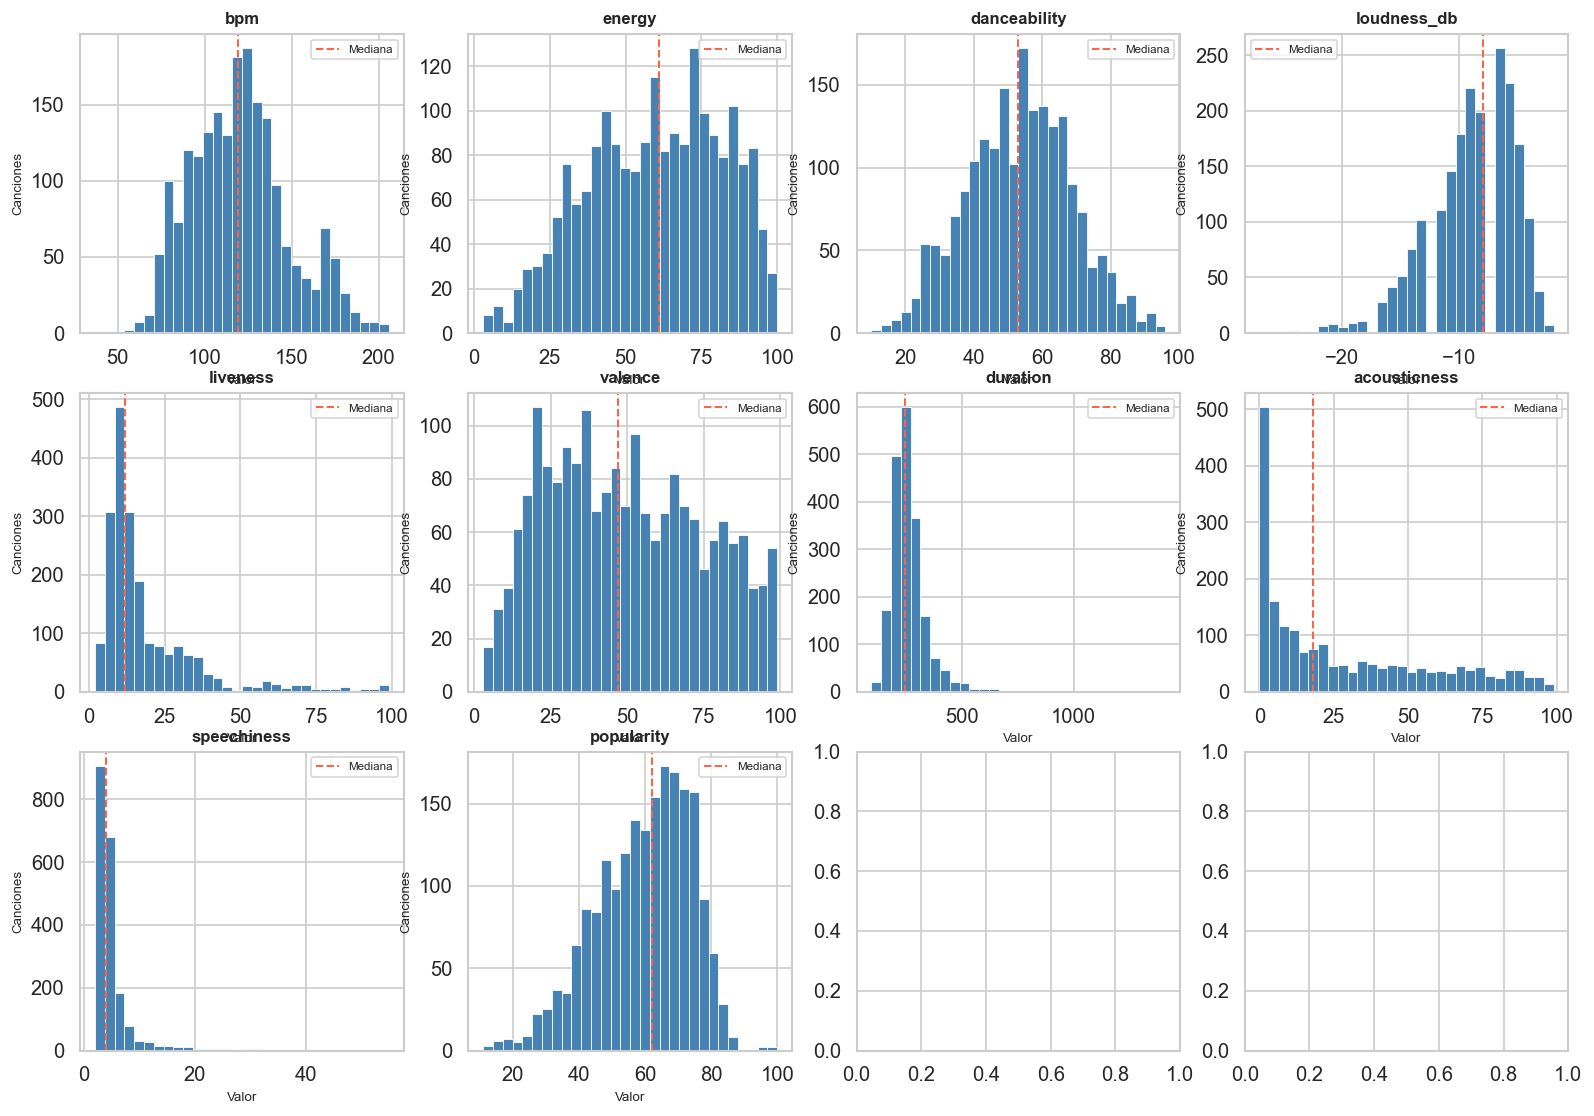

In [48]:
# Creamos una cuadrícula 3×4 de subgráficas (una por atributo)
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()  # Convertimos la matriz 3×4 en una lista plana para iterar fácilmente

for i, col in enumerate(ATRIBUTOS):
    axes[i].hist(
        df[col].dropna(),  # dropna() ignora los valores nulos
        bins=30,                   # Número de intervalos
        color='steelblue',
        edgecolor='white',
        linewidth=0.5
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=8)
    axes[i].set_ylabel('Canciones', fontsize=8)

    # Línea vertical roja en la mediana — referencia visual rápida
    axes[i].axvline(
        df[col].median(),
        color='tomato', linestyle='--', linewidth=1.2, label='Mediana'
    )
    axes[i].legend(fontsize=7)

In [49]:
# Ocultamos los subplots sobrantes (tenemos 10 variables y 12 subplots → 2 vacíos)
for j in range(len(ATRIBUTOS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de atributos acústicos — Spotify 2000',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

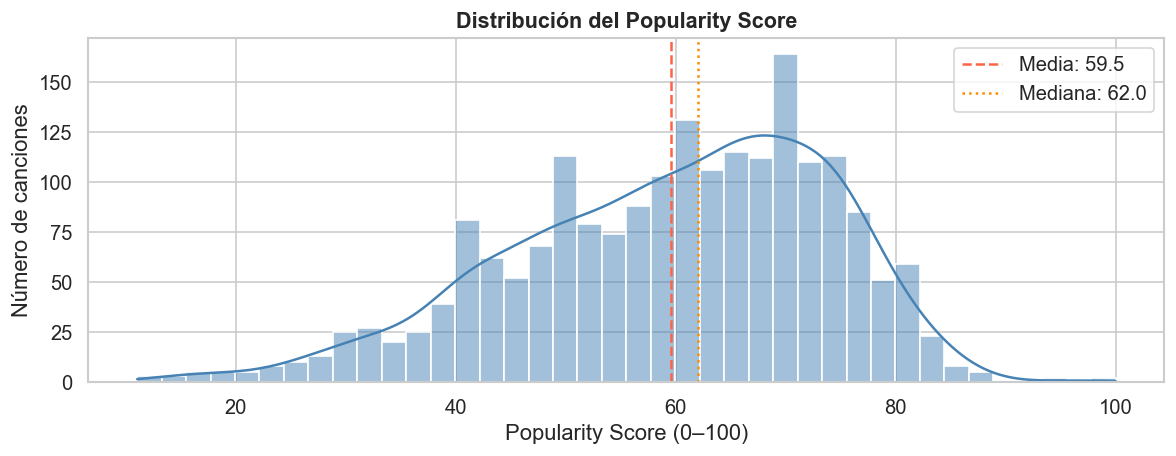

Media:   59.5
Mediana: 62.0
Std:     14.4


In [50]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(df['popularity'], bins=40, kde=True, ax=ax, color='steelblue')

# Líneas de referencia: media (promedio aritmético) y mediana (valor central)
# Si están muy separadas, la distribución es asimétrica
ax.axvline(
    df['popularity'].mean(),
    color='tomato', linestyle='--',
    label=f'Media: {df["popularity"].mean():.1f}'
)
ax.axvline(
    df['popularity'].median(),
    color='darkorange', linestyle=':',
    label=f'Mediana: {df["popularity"].median():.1f}'
)

ax.set_title('Distribución del Popularity Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Número de canciones')
ax.legend()
plt.tight_layout()
plt.show()

# Resumen numérico en consola
print(f'Media:   {df["popularity"].mean():.1f}')
print(f'Mediana: {df["popularity"].median():.1f}')
print(f'Std:     {df["popularity"].std():.1f}')

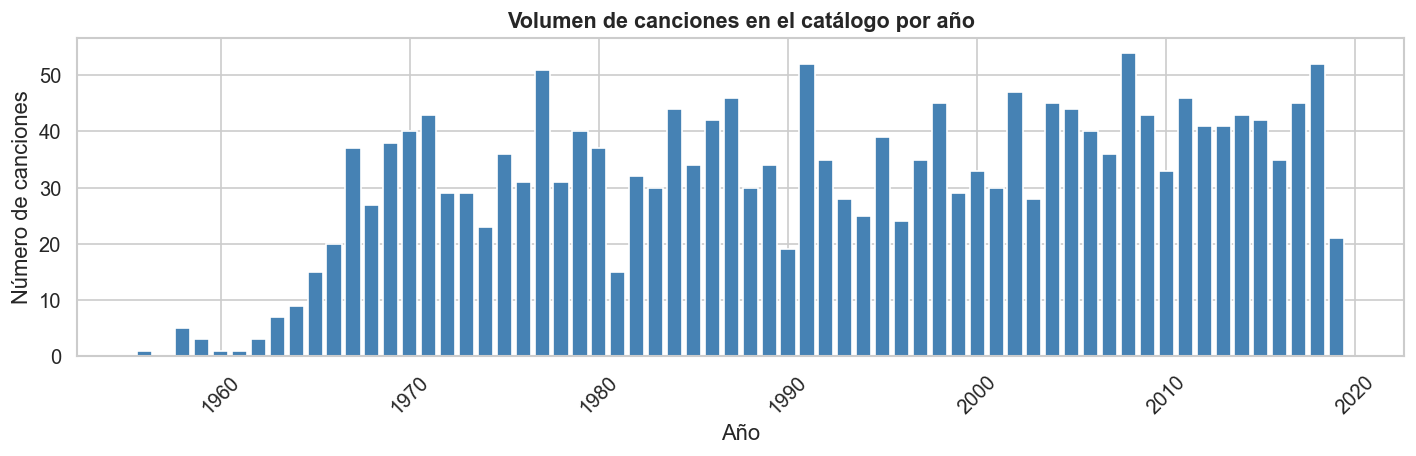

In [51]:
canciones_por_anio = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    canciones_por_anio.index,
    canciones_por_anio.values,
    color='steelblue',
    edgecolor='white'
)
ax.set_title('Volumen de canciones en el catálogo por año',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de canciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

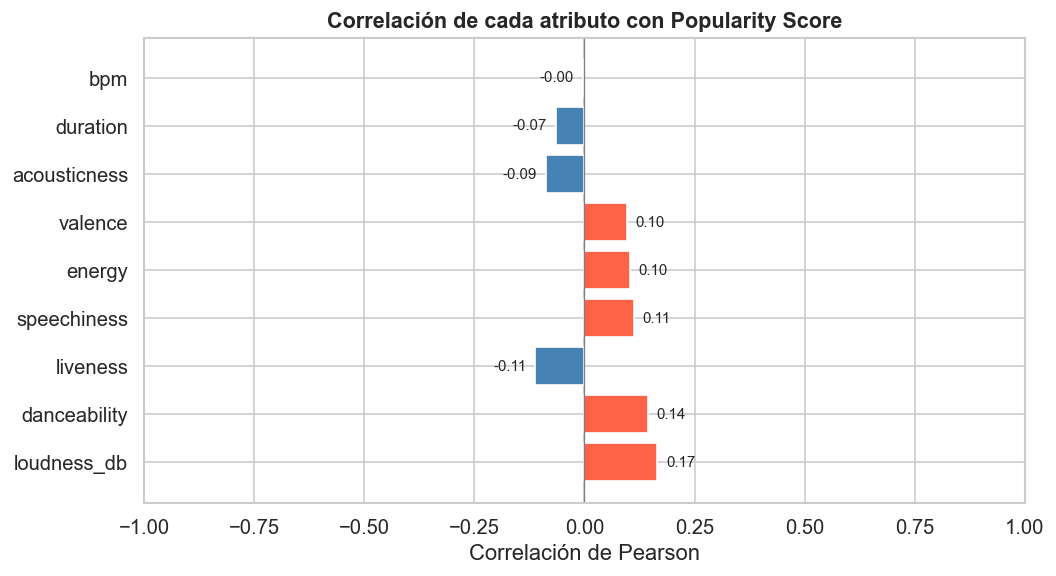

Correlaciones con popularity (mayor impacto primero):
loudness_db     0.166
danceability    0.144
liveness       -0.112
speechiness     0.112
energy          0.103
valence         0.096
acousticness   -0.088
duration       -0.065
bpm            -0.003


In [53]:
# Ranking de correlaciones con popularity


corr_con_popularity = (
    matriz_corr['popularity']
    .drop('popularity')                      # Quitamos r=1 (popularity consigo misma)
    .sort_values(key=abs, ascending=False)   # Ordenamos por magnitud
)

# Rojo = correlación positiva (más del atributo → más popular)
# Azul = correlación negativa (más del atributo → menos popular)
fig, ax = plt.subplots(figsize=(9, 5))
colores = ['tomato' if v > 0 else 'steelblue' for v in corr_con_popularity.values]
ax.barh(corr_con_popularity.index, corr_con_popularity.values,
        color=colores, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de cada atributo con Popularity Score',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.set_xlim(-1, 1)

for i, (val, _) in enumerate(zip(corr_con_popularity.values, corr_con_popularity.index)):
    ax.text(
        val + (0.02 if val >= 0 else -0.02), i,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print('Correlaciones con popularity (mayor impacto primero):')
print(corr_con_popularity.round(3).to_string())

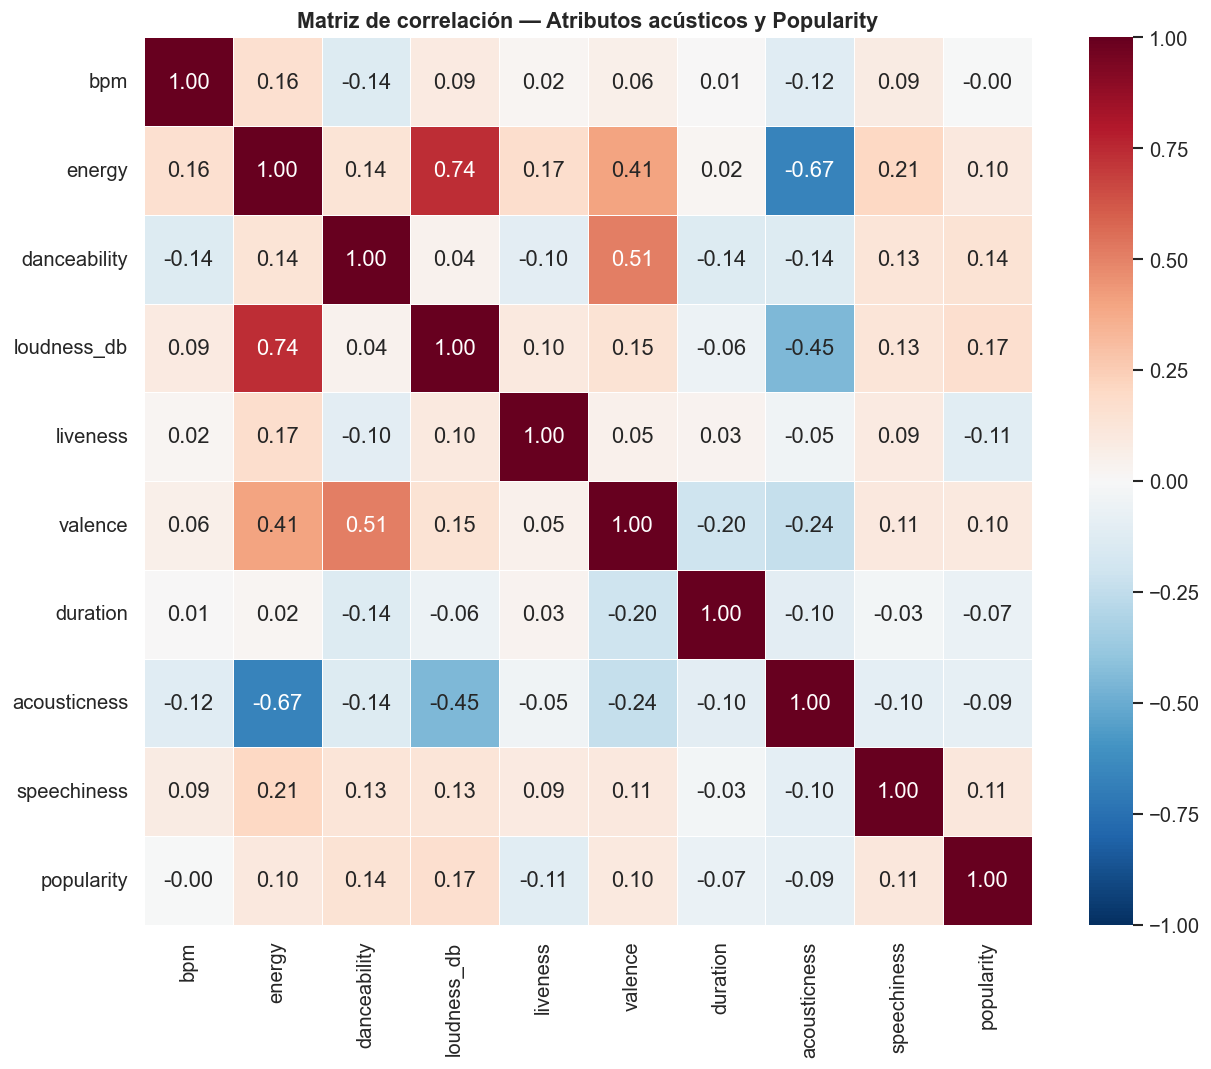

In [52]:
## Correlaciones con Popularity

### Matriz de correlación

matriz_corr = df[ATRIBUTOS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    matriz_corr,
    annot=True,       
    fmt='.2f',        
    cmap='RdBu_r',   
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.4,
    ax=ax
)
ax.set_title('Matriz de correlación — Atributos acústicos y Popularity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

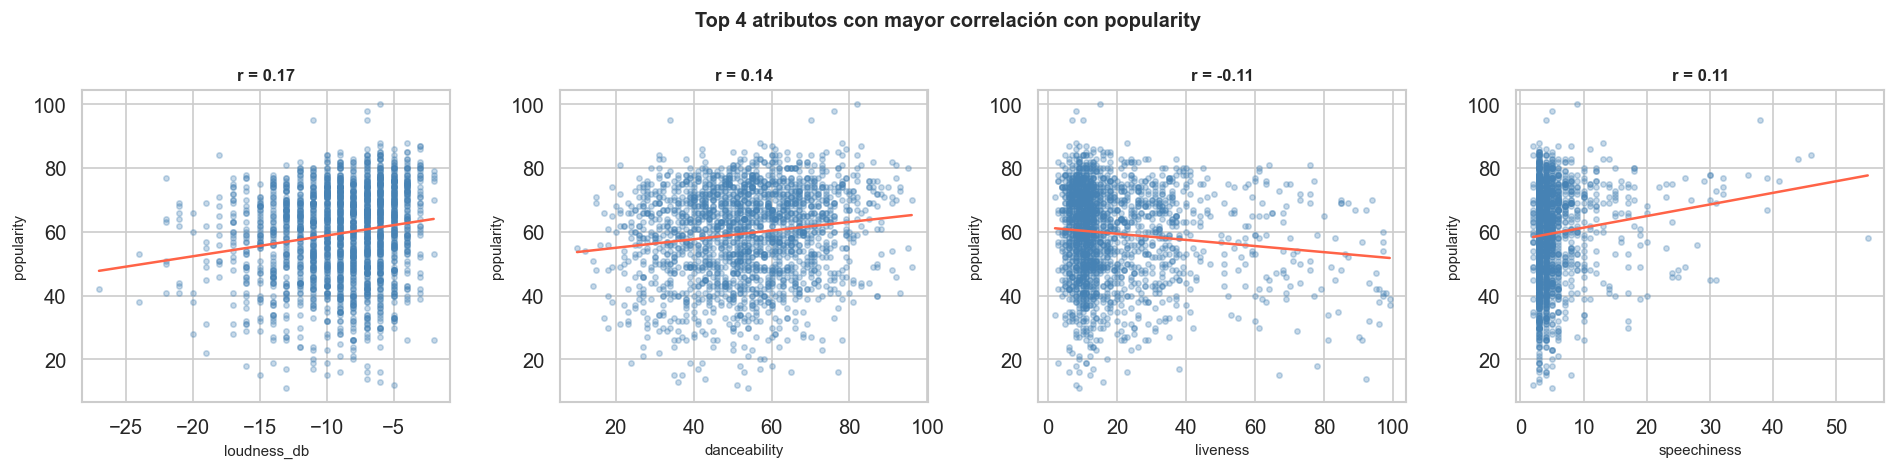

In [54]:
# Scatterplots — Top 4 atributos vs popularity

# Identificamos automáticamente los 4 atributos con mayor |r|
top4_atributos = corr_con_popularity.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, top4_atributos):
    ax.scatter(
        df[col],
        df['popularity'],
        alpha=0.3,   # Transparencia para ver dónde se acumulan los puntos
        s=10,
        color='steelblue'
    )

    # np.polyfit calcula la pendiente (m) e intercepto (b) de la línea de tendencia
    m, b = np.polyfit(df[col].dropna(),
                      df.loc[df[col].notna(), 'popularity'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5)

    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('popularity', fontsize=9)
    ax.set_title(f'r = {corr_con_popularity[col]:.2f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Top 4 atributos con mayor correlación con popularity',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

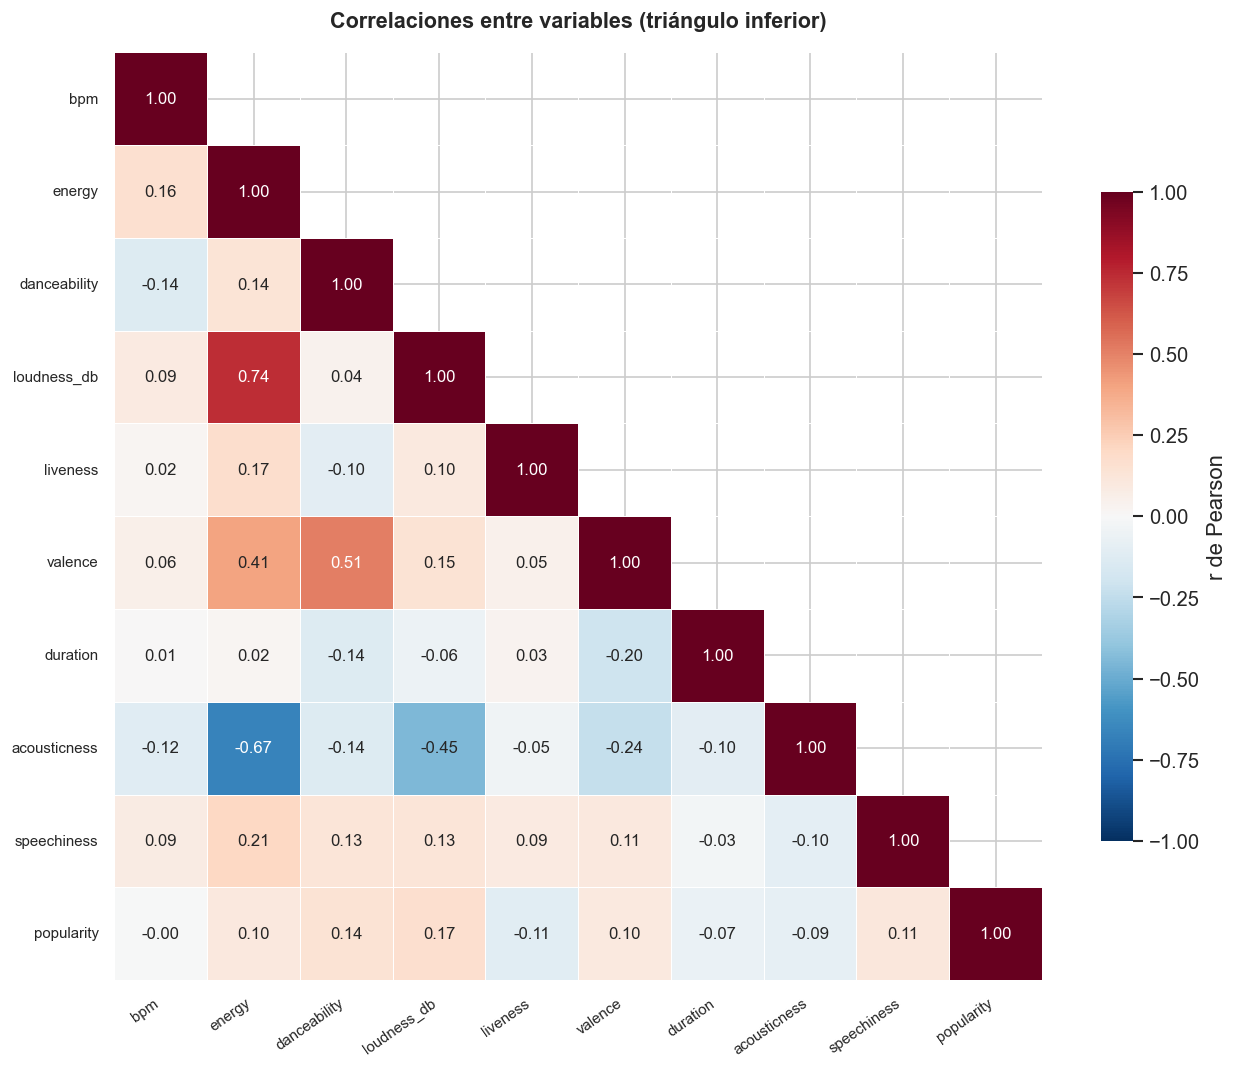

In [56]:
###  Mapa de calor — Solo triángulo inferior (versión limpia)
matriz_ordenada = df[ATRIBUTOS].corr()  # sin reordenamiento jerárquico

fig, ax = plt.subplots(figsize=(11, 9))

# mask=True en la parte superior → esas celdas no se dibujan
mask = np.triu(np.ones_like(matriz_ordenada, dtype=bool), k=1)

sns.heatmap(
    matriz_ordenada,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10},
    ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'r de Pearson'}
)

ax.set_title('Correlaciones entre variables (triángulo inferior)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [57]:
### Pares de variables con correlación más fuerte

# Tomamos el triángulo superior de la matriz para no repetir pares
corr_upper = matriz_corr.where(
    np.triu(np.ones(matriz_corr.shape), k=1).astype(bool)
)

# Convertimos a Serie, eliminamos NaN y ordenamos por valor absoluto
pares = (
    corr_upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'r'})
    .assign(abs_r=lambda x: x['r'].abs())
    .sort_values('abs_r', ascending=False)
    .drop(columns='abs_r')
    .reset_index(drop=True)
)

print('── Top 10 pares con mayor correlación ──')
print(pares.head(10).to_string(index=False))
print()
print('── Top 5 correlaciones POSITIVAS ──')
print(pares[pares['r'] > 0].head(5).to_string(index=False))
print()
print('── Top 5 correlaciones NEGATIVAS ──')
print(pares[pares['r'] < 0].head(5).to_string(index=False))

── Top 10 pares con mayor correlación ──
  Variable 1   Variable 2         r
      energy  loudness_db  0.735711
      energy acousticness -0.665156
danceability      valence  0.514564
 loudness_db acousticness -0.451635
      energy      valence  0.405175
     valence acousticness -0.239729
      energy  speechiness  0.205865
     valence     duration -0.203690
      energy     liveness  0.174118
 loudness_db   popularity  0.165527

── Top 5 correlaciones POSITIVAS ──
  Variable 1  Variable 2        r
      energy loudness_db 0.735711
danceability     valence 0.514564
      energy     valence 0.405175
      energy speechiness 0.205865
      energy    liveness 0.174118

── Top 5 correlaciones NEGATIVAS ──
 Variable 1   Variable 2         r
     energy acousticness -0.665156
loudness_db acousticness -0.451635
    valence acousticness -0.239729
    valence     duration -0.203690
        bpm danceability -0.140602


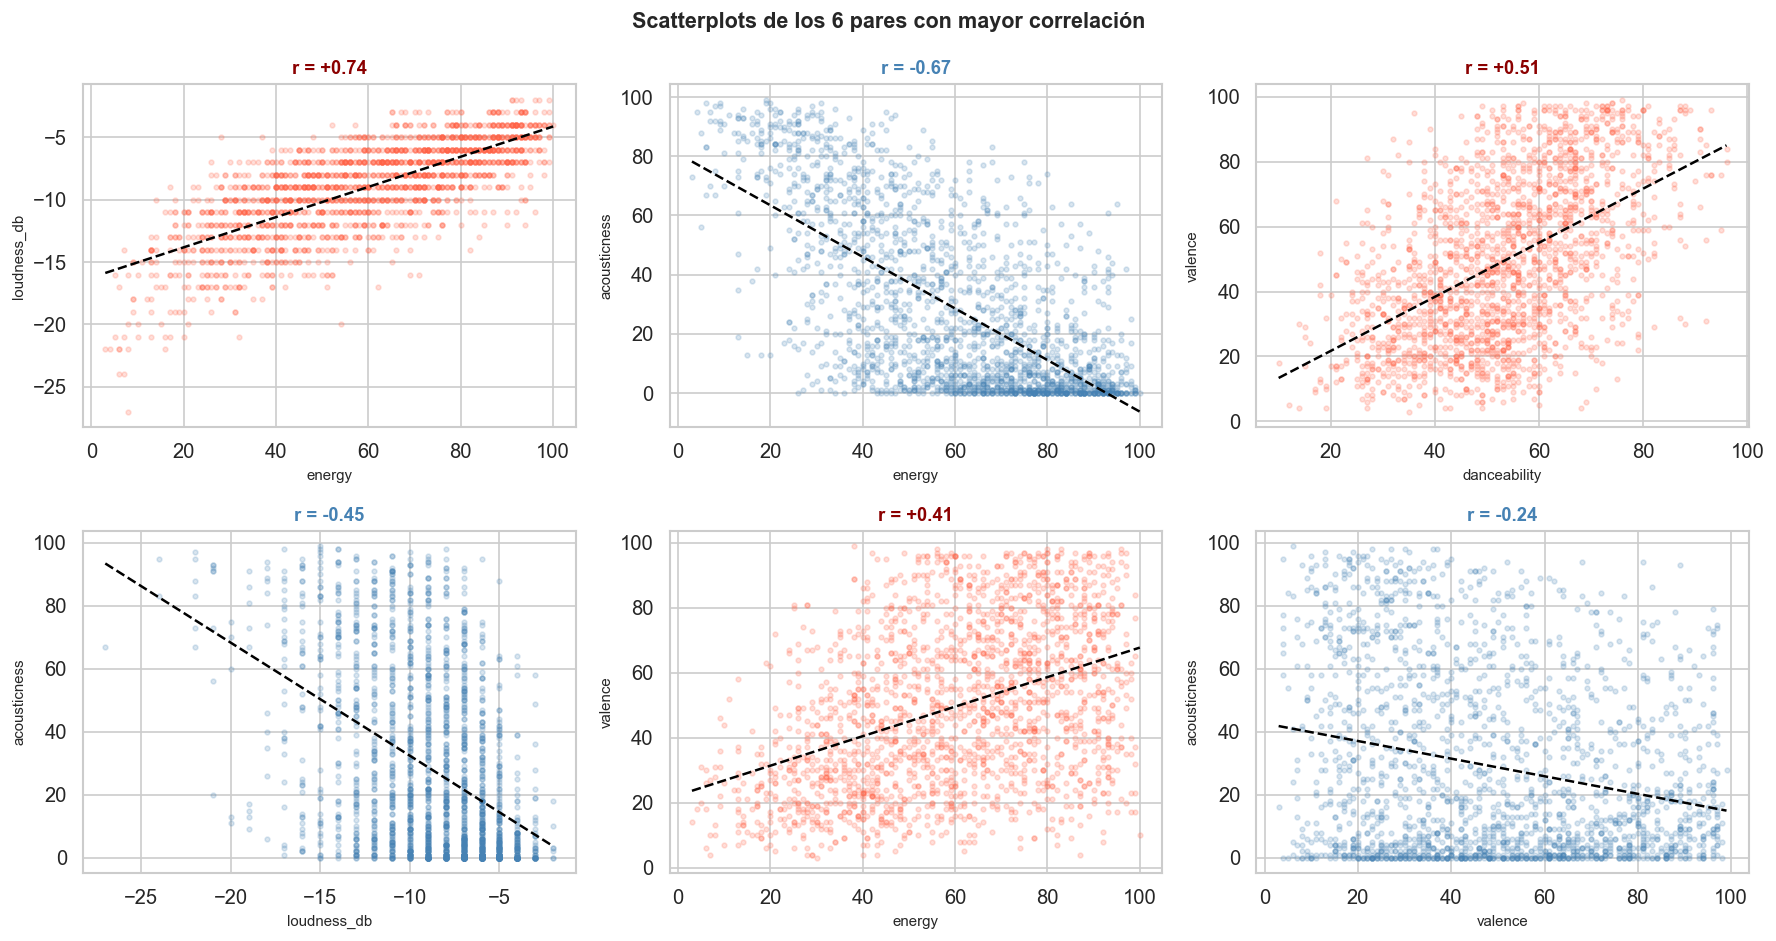

  INTERPRETACIÓN — Relaciones entre variables
  energy ↔ loudness_db
    r = 0.74 → correlación positiva muy fuerte

  energy ↔ acousticness
    r = -0.67 → correlación negativa fuerte

  danceability ↔ valence
    r = 0.51 → correlación positiva fuerte

  loudness_db ↔ acousticness
    r = -0.45 → correlación negativa moderada

  energy ↔ valence
    r = 0.41 → correlación positiva moderada

  valence ↔ acousticness
    r = -0.24 → correlación negativa moderada



In [58]:
### Interpretación de las relaciones clave

top6_pares = pares.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(top6_pares.iterrows()):
    v1, v2, r = row['Variable 1'], row['Variable 2'], row['r']

    color = 'tomato' if r > 0 else 'steelblue'

    axes[i].scatter(df[v1], df[v2], alpha=0.2, s=8, color=color)

    # Línea de tendencia
    m, b = np.polyfit(df[v1], df[v2], 1)
    x_line = np.linspace(df[v1].min(), df[v1].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

    axes[i].set_xlabel(v1, fontsize=9)
    axes[i].set_ylabel(v2, fontsize=9)
    signo = '+' if r > 0 else ''
    axes[i].set_title(f'r = {signo}{r:.2f}', fontsize=11, fontweight='bold',
                      color='darkred' if r > 0 else 'steelblue')

plt.suptitle('Scatterplots de los 6 pares con mayor correlación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen interpretativo
print('=' * 55)
print('  INTERPRETACIÓN — Relaciones entre variables')
print('=' * 55)
for _, row in top6_pares.iterrows():
    v1, v2, r = row['Variable 1'], row['Variable 2'], row['r']
    direccion = 'positiva' if r > 0 else 'negativa'
    intensidad = 'muy fuerte' if abs(r) > 0.7 else 'fuerte' if abs(r) > 0.5 else 'moderada'
    print(f'  {v1} ↔ {v2}')
    print(f'    r = {r:.2f} → correlación {direccion} {intensidad}')
    print()